# Spatial Harmonization - Point-Grid Integration and Contextual Joins

**Part 4 of the AQ Integration module.**

Parts 1 and 2 extracted gridded data at the station coordinates using a
single method choice (nearest pixel, in some cases a buffer mean) and
proceeded onward. Part 3 placed every series onto a shared **time
axis**. This notebook addresses the **spatial** dimension of the
harmonisation with the same degree of rigour:

1. **CRS consistency** - every input (grid, stations, contextual layers)
   must declare the same coordinate reference system, or be reprojected.
2. **Point-to-grid matching method** — nearest neighbour, bilinear
   interpolation, or a buffer mean - selected according to the grid
   resolution and the intended use case.
3. **Contextual joins** (optional) - attaching land cover, altitude, or
   proximity indicators from a vector layer to each station.
4. **Documentation, not QA/QC** - urban-canyon and microenvironment
   issues are recorded in the *station registry* rather than silently
   corrected.

Upon completion of this notebook, you will be able to:

- execute a defensible CRS check prior to any extraction,
- select a mapping method for each (grid, variable) pair and record
  that selection,
- produce a fully documented **location registry**,
- construct a merged dataset indexed by `(time, location_id)` that is
  ready for the modelling stage.

---

## Spatial Pitfalls

### CRS Mismatches

CAMS, ERA5, and OpenAQ-style station files all use **WGS84** decimal
degrees (`EPSG:4326`). Land-cover layers and national products are
frequently distributed in **projected** CRSes (for example, the Urban
Atlas in `EPSG:3035`). **Practical guideline.** Verify the CRS at the point of
ingestion, then convert *once*.

### Point-to-Grid Mapping Methods

No single method is universally correct; the choice must reflect the
grid resolution, the smoothness of the field, and the intended use case:

| Method            | When to use                                                                |
| ----------------- | -------------------------------------------------------------------------- |
| **Nearest**       | Default. Fast, no interpolation artefacts. Appropriate when the pixel is small. |
| **Bilinear**      | Smooth continuous fields (T, p, wind components). Avoid for accumulations. |
| **Buffer mean**   | Coarse grids, regionally representative stations, smoothing pixel noise.   |

The selected method is recorded in the `method` column of the output
alongside the value, ensuring that any reader of the final table can
identify how each value was obtained.

### Representativeness (Urban Canyon, Microenvironment)

A station situated inside a street canyon, adjacent to a parking lot,
or on the roof of a tall building observes the atmosphere differently
from the surrounding 0.1° CAMS pixel. Such differences are **not**
corrected at the integration stage; they are documented in the
**station registry** through the `type` field
(background / traffic / industrial / ...) and the free-text `notes`
field, so that downstream code and analysts can determine the
appropriate response.

### Contextual Layers

Land cover, altitude, and proximity to roads or industry are static
attributes. They are attached once per station rather than once per
timestamp. The result is a compact "context" table that is joined into
the final output by `location_id`.

## Setup Procedure

In [16]:
import warnings 
warnings.filterwarnings("ignore", category=FutureWarning)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [12]:
_scripts_root = Path.cwd().parent.parent / "scripts"
if not _scripts_root.exists():
    _scripts_root = Path.cwd().parent / "scripts" 
sys.path.insert(0, str(_scripts_root))
sys.path.insert(0, str(_scripts_root / "part4_spatial"))

import spatial_match as sm
import station_registry_builder as srb
from utils import _load_data 

## Construction of the Station Registry

Parts 1, 2, and 3 require only a minimal `(location_id, lat, lon)`
table. Part 4 enriches that table with the descriptive metadata on
which the *spatial* step depends:

- `type` - site classification (background / traffic / ...), which
  governs the choice of mapping method.
- `height_m` - sensor inlet height above ground level (NaN where
  unknown).
- `notes` - free text describing the urban-canyon situation, known
  equipment, and similar contextual information.

The registry is maintained in **WGS84 (EPSG:4326)** decimal degrees.

In [3]:
base = pd.read_csv("../../data/stations_example.csv")
print(f"Base table: {len(base)} stations")
base

Base table: 5 stations


,location_id,station_name,lat,lon,country
0,ZAGREB01,Zagreb,45.8150,15.9819,HR
1,SPLIT01,Split,43.5081,16.4402,HR
2,RIJEKA01,Rijeka,45.3271,14.4422,HR
3,OSIJEK01,Osijek,45.5511,18.6939,HR
4,ZADAR01,Zadar,44.1194,15.2314,HR


In [4]:
registry = srb.build_registry(
    base,
    defaults={"type": "background", "height_m": 2.0},
    overrides={
        "ZAGREB01": {
            "type": "traffic",
            "height_m": 3.0,
            "notes": "City-centre site, partial urban canyon",
        },
        "RIJEKA01": {
            "type": "suburban",
            "notes": "Coastal influence; sea breeze regime",
        },
        "OSIJEK01": {
            "type": "background",
            "notes": "Pannonian plain; agricultural surroundings",
        },
    },
)

report = srb.validate_registry(registry)
srb.print_report(report)
registry

Registry validation: OK  (5 rows)


,location_id,station_name,country,lat,lon,type,height_m,notes
0,ZAGREB01,Zagreb,HR,45.8150,15.9819,traffic,3.0,"City-centre site, partial urban canyon"
1,SPLIT01,Split,HR,43.5081,16.4402,background,2.0,
2,RIJEKA01,Rijeka,HR,45.3271,14.4422,suburban,2.0,Coastal influence; sea breeze regime
3,OSIJEK01,Osijek,HR,45.5511,18.6939,background,2.0,Pannonian plain; agricultural surroundings
4,ZADAR01,Zadar,HR,44.1194,15.2314,background,2.0,


In [5]:
out_dir = Path("../../data/outputs")
out_dir.mkdir(parents=True, exist_ok=True)
registry_path = out_dir / "station_registry.csv"
srb.save_registry(registry, str(registry_path))
print(f"Wrote {registry_path}")

Wrote ..\..\data\outputs\station_registry.csv


## Construction of a Synthetic Grid for Demonstration

So that sections 5 and 6 execute without any downloads, the notebook
constructs a small synthetic field over Croatia on a regular WGS84
grid. The field consists of a smooth gradient with additive noise -
sufficient to render the differences among the nearest, bilinear, and
buffer methods visible.

In [6]:
lats = np.arange(42.5, 47.0 + 1e-9, 0.1)
lons = np.arange(13.5, 19.5 + 1e-9, 0.1)

LAT, LON = np.meshgrid(lats, lons, indexing="ij")
rng = np.random.default_rng(0)
field = (
    10.0
    + 1.5 * (LAT - 45.0)         # north-south gradient
    + 0.8 * (LON - 16.5)         # east-west gradient
    + rng.normal(0.0, 0.6, LAT.shape)
)

synthetic = xr.DataArray(
    field,
    dims=("latitude", "longitude"),
    coords={"latitude": lats, "longitude": lons},
    name="pm2p5_demo",
    attrs={"product_name": "synthetic_demo_grid", "crs": "EPSG:4326"},
)
synthetic

<xarray.DataArray 'pm2p5_demo' (latitude: 46, longitude: 61)> Size: 22kB
array([[ 3.92543813,  3.85073708,  4.39425359, ...,  7.77952922,
         8.17297846,  8.38813885],
       [ 3.29811886,  5.12362073,  3.86245356, ...,  9.33891839,
         9.19255293,  9.30644721],
       [ 4.19535617,  3.37393569,  4.22897294, ...,  8.66728651,
         8.24428392,  9.31787388],
       ...,
       [10.17812595, 10.31077701,  9.32073012, ..., 14.6573786 ,
        14.58424316, 14.72192497],
       [10.66229822, 10.82076376, 10.08513228, ..., 15.24716483,
        14.4303899 , 15.53824914],
       [10.20170869, 10.95893512, 11.25570516, ..., 15.77868704,
        15.4788495 , 14.8131839 ]], shape=(46, 61))
Coordinates:
  * latitude   (latitude) float64 368B 42.5 42.6 42.7 42.8 ... 46.8 46.9 47.0
  * longitude  (longitude) float64 488B 13.5 13.6 13.7 13.8 ... 19.3 19.4 19.5
Attributes:
    product_name:  synthetic_demo_grid
    crs:           EPSG:4326

## CRS Consistency Check

Prior to any extraction, execute `crs_check`. The function does **not**
reproject; it verifies only that:

1. the grid and the registry declare the same CRS,
2. the coordinates are consistent with WGS84 (latitude in [-90, 90],
   longitude in [-180, 180] or [0, 360]),
3. every station falls within the grid footprint.

A passing check returns a report with `ok=True`; otherwise the
`issues` field enumerates the failures.

In [7]:
ok_report = sm.crs_check(synthetic, registry)
print(f"OK?  {ok_report.ok}")
print(f"Grid CRS: {ok_report.grid_crs}")
print(f"Stations CRS: {ok_report.stations_crs}")
for issue in ok_report.issues:
    print(f"  - {issue}")

OK?  True
Grid CRS: EPSG:4326
Stations CRS: EPSG:4326


In [8]:
bad_grid = synthetic.copy()
bad_grid.attrs["crs"] = "EPSG:3035"
bad_report = sm.crs_check(bad_grid, registry)
print(f"OK?  {bad_report.ok}")
for issue in bad_report.issues:
    print(f"  - {issue}")

OK?  False
  - Grid CRS is 'EPSG:3035', expected 'EPSG:4326'. Reproject the grid (or the stations) before extracting.


## Point-to-Grid Matching: Comparison of Three Methods

In [9]:
near = sm.nearest_grid_value(synthetic, variable=None, stations=registry)
bili = sm.bilinear_grid_value(synthetic, variable=None, stations=registry)
buff = sm.buffer_average(
    synthetic, variable=None, stations=registry, radius_km=20.0
)

side_by_side = (
    pd.concat([near, bili, buff], ignore_index=True)
    .pivot_table(
        index="location_id", columns="method", values="value", aggfunc="first"
    )
    .round(3)
)
side_by_side

method,bilinear,buffer_mean_20km,nearest
location_id,,,
OSIJEK01,12.044,12.323,11.819
RIJEKA01,8.800,8.620,8.714
SPLIT01,7.618,7.666,7.631
ZADAR01,7.458,7.616,7.521
ZAGREB01,9.783,10.715,9.502


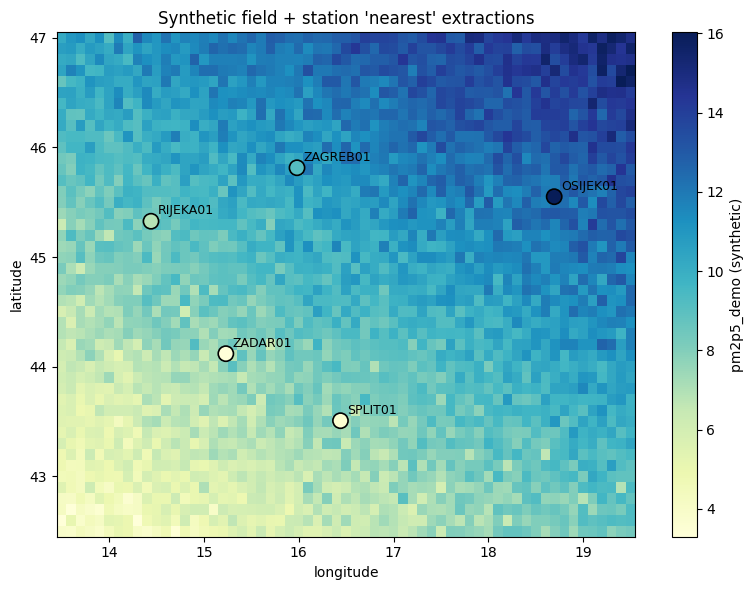

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
synthetic.plot(
    ax=ax, cmap="YlGnBu", add_colorbar=True,
    cbar_kwargs={"label": "pm2p5_demo (synthetic)"},
)
ax.scatter(
    registry["lon"], registry["lat"],
    c=near["value"], cmap="YlGnBu",
    edgecolor="black", linewidth=1.2, s=120, zorder=3,
)
for _, st in registry.iterrows():
    ax.annotate(
        st["location_id"], (st["lon"], st["lat"]),
        xytext=(5, 5), textcoords="offset points", fontsize=9,
    )
ax.set_title("Synthetic field + station 'nearest' extractions")
plt.tight_layout()
plt.show()

## Spatial Match on the Real CAMS Field 

CAMS European AQ has a resolution of approximately 0.1° (~10 km).
Nearest neighbour is generally the appropriate default for urban
sites; rural background stations may benefit from a 20 km buffer
mean.

In [14]:
CAMS_PATH = Path("../../data/cams_pm25_croatia.nc")

if CAMS_PATH.exists():
    cams = _load_data(CAMS_PATH)
    if "time" in cams.coords and not np.issubdtype(
        cams["time"].dtype, np.datetime64
    ):
        hours = np.asarray(cams["time"].values, dtype="float64")
        real_times = pd.Timestamp("2024-06-01") + pd.to_timedelta(hours, unit="h")
        cams = cams.assign_coords(time=("time", real_times.to_numpy()))

    var = next(
        (v for v in cams.data_vars if "particulate" in v or "pm" in v.lower()),
        list(cams.data_vars)[0],
    )

    field = cams[var]
    if "level" in field.dims:
        field = field.isel(level=0).drop_vars("level", errors="ignore")

    print(f"CAMS CRS check on '{var}':")
    rep = sm.crs_check(field, registry)
    for line in rep.issues:
        print(f"  - {line}")
    if rep.ok:
        print("  OK")

    cams_nearest = sm.nearest_grid_value(
        field, variable=None, stations=registry, source="CAMS European AQ analysis"
    )
    cams_buffer = sm.buffer_average(
        field, variable=None, stations=registry,
        radius_km=15.0, source="CAMS European AQ analysis",
    )

    print(f"\nCAMS rows: nearest={len(cams_nearest)}, buffer={len(cams_buffer)}")
    cams_nearest.head()
else:
    print(f"CAMS file not found at {CAMS_PATH} — skipping section 7.")
    cams_nearest = pd.DataFrame()
    cams_buffer = pd.DataFrame()

CAMS CRS check on 'pm2p5':
  OK

CAMS rows: nearest=3600, buffer=3600


## Spatial Match on the Real ERA5 Field

ERA5 has a resolution of approximately 0.25° (~28 km). Temperature is
a smooth, continuous field for which bilinear interpolation is
appropriate.

This section extracts `t2m` (2 m temperature), the same variable
plotted in the Part 2 notebook.

In [17]:
ERA5_PATH = Path("../../data/era5_meteo_croatia.nc")

if ERA5_PATH.exists():
    era5 = _load_data(ERA5_PATH)

    if "t2m" in era5.data_vars:
        t2m = era5["t2m"]
        rep = sm.crs_check(t2m, registry)
        if not rep.ok:
            for line in rep.issues:
                print(f"  - {line}")

        era_bilinear = sm.bilinear_grid_value(
            t2m, variable=None, stations=registry, source="ERA5 reanalysis"
        )
        era_nearest = sm.nearest_grid_value(
            t2m, variable=None, stations=registry, source="ERA5 reanalysis"
        )
        print(f"ERA5 t2m rows: bilinear={len(era_bilinear)}, nearest={len(era_nearest)}")
        era_bilinear.head()
    else:
        print(f"`t2m` not in ERA5 dataset (vars: {list(era5.data_vars)})")
        era_bilinear = pd.DataFrame()
        era_nearest = pd.DataFrame()
else:
    print(f"ERA5 file not found at {ERA5_PATH} — skipping section 8.")
    era_bilinear = pd.DataFrame()
    era_nearest = pd.DataFrame()

ERA5 t2m rows: bilinear=3600, nearest=3600


## Optional Contextual Join: Land Cover from the Urban Atlas

If you prepared the Zagreb Urban Atlas FGB, a
land-cover class can be attached to each station. Only ZAGREB01 lies
inside the Zagreb FUA, so the remaining rows will be returned with
NaN, which itself constitutes an integration-stage diagnostic.

In [18]:
from pathlib import Path

UA_PATH = Path(
    "../../data/"
    "CLMS_UA_LCU_S2021_V025ha_HR001L2_GRAD_ZAGREB_03035_V01_R01_20250321.fgb"
)

if UA_PATH.exists():
    land_use = sm.join_contextual_layer(
        registry,
        str(UA_PATH),
        attribute="code_2021",
        method="intersect",
        buffer_m=50.0,  # tolerance for boundary cases
    )
    print("Land-use class attached to each station (code_2021):")
    print(land_use[["location_id", "lat", "lon", "code_2021"]].to_string(index=False))
else:
    print(f"Urban Atlas FGB not found at {UA_PATH} — skipping section 9.")
    land_use = registry.copy()
    land_use["code_2021"] = pd.NA

Land-use class attached to each station (code_2021):
location_id     lat     lon code_2021
   ZAGREB01 45.8150 15.9819     12220
   ZAGREB01 45.8150 15.9819     12100
   ZAGREB01 45.8150 15.9819     14110
   ZAGREB01 45.8150 15.9819     11210
    SPLIT01 43.5081 16.4402       NaN
   RIJEKA01 45.3271 14.4422       NaN
   OSIJEK01 45.5511 18.6939       NaN
    ZADAR01 44.1194 15.2314       NaN


## 10. Merge into the Final `(time, location_id)` Table

Two tables are now available:

- a long-format **temporal** table from Part 3 (`aligned_long.csv`)
  whose rows are keyed by `(time, location_id, variable, source)`,
- a per-station **context** table produced by this notebook (land
  cover, station type, height, and notes).

Joining them on `location_id` yields the dataset that every
downstream model expects.

In [19]:
ALIGNED_PATH = Path("../../data/outputs/aligned_long.csv")

if ALIGNED_PATH.exists():
    aligned = pd.read_csv(ALIGNED_PATH, parse_dates=["time"])

    context_cols = ["location_id", "type", "height_m", "notes"]
    if "code_2021" in land_use.columns:
        context_cols.append("code_2021")
    context = land_use[context_cols].drop_duplicates("location_id")

    merged = aligned.merge(context, on="location_id", how="left")
    out_path = Path("../../data/outputs/spatial_temporal_long.csv")
    merged.to_csv(out_path, index=False)
    print(f"Wrote {out_path}  ({len(merged):,} rows)")
    merged.head()
else:
    print(f"Part 3 aligned table not found at {ALIGNED_PATH} — skipping merge.")
    merged = pd.DataFrame()

Wrote ..\..\data\outputs\spatial_temporal_long.csv  (32,390 rows)


In [20]:
merged

,time,location_id,source,variable,lat,lon,method,value,dataset_version,type,height_m,notes,code_2021
0,2024-06-01 00:00:00+00:00,OSIJEK01,ground_station_synth,pm2p5,45.5511,18.6939,mean_1h_left,4.442551,NaN,background,2.0,Pannonian plain; agricultural surroundings,NaN
1,2024-06-01 01:00:00+00:00,OSIJEK01,ground_station_synth,pm2p5,45.5511,18.6939,mean_1h_left,4.361992,NaN,background,2.0,Pannonian plain; agricultural surroundings,NaN
2,2024-06-01 02:00:00+00:00,OSIJEK01,ground_station_synth,pm2p5,45.5511,18.6939,mean_1h_left,4.969800,NaN,background,2.0,Pannonian plain; agricultural surroundings,NaN
3,2024-06-01 03:00:00+00:00,OSIJEK01,ground_station_synth,pm2p5,45.5511,18.6939,mean_1h_left,6.113048,NaN,background,2.0,Pannonian plain; agricultural surroundings,NaN
4,2024-06-01 04:00:00+00:00,OSIJEK01,ground_station_synth,pm2p5,45.5511,18.6939,mean_1h_left,8.943091,NaN,background,2.0,Pannonian plain; agricultural surroundings,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32385,2024-06-30 23:00:00+00:00,OSIJEK01,reanalysis,t2m,45.5511,18.6939,bilinear,298.118659,history=2026-05-20T14:24 GRIB to CDM+CF via cf...,background,2.0,Pannonian plain; agricultural surroundings,NaN
32386,2024-06-30 23:00:00+00:00,OSIJEK01,reanalysis,d2m,45.5511,18.6939,bilinear,294.187139,history=2026-05-20T14:24 GRIB to CDM+CF via cf...,background,2.0,Pannonian plain; agricultural surroundings,NaN
32387,2024-06-30 23:00:00+00:00,OSIJEK01,reanalysis,sp,45.5511,18.6939,bilinear,99892.879623,history=2026-05-20T14:24 GRIB to CDM+CF via cf...,background,2.0,Pannonian plain; agricultural surroundings,NaN
32388,2024-06-30 23:00:00+00:00,OSIJEK01,reanalysis,blh,45.5511,18.6939,bilinear,91.660846,history=2026-05-20T14:24 GRIB to CDM+CF via cf...,background,2.0,Pannonian plain; agricultural surroundings,NaN


## Summary

You have constructed the spatial backbone of the integration stage:

1. Built a **station registry** containing `type`, `height_m`, and
   `notes`, then validated and saved it.
2. Executed a defensible **CRS check** prior to any extraction.
3. Mapped a gridded field to stations using three methods
   (**nearest** / **bilinear** / **buffer mean**) and compared the
   results.
4. Applied the same workflow to the real **CAMS** and **ERA5**
   fields.
5. Attached a **contextual** layer (Urban Atlas land cover) to each
   station using a single CRS-aware spatial join.
6. Merged the temporal long-format table from Part 3 with the
   per-station context into a single file,
   `data/outputs/spatial_temporal_long.csv`.
